<a href="https://colab.research.google.com/github/idarwati/Health-Data-Analytics-Portfolio/blob/NLP/Learn_Python_07_12_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. MEMBUAT DATA DUMMY (Simulasi Data Media Sosial)
data_sosmed = {
    'username': ['user123', 'warga_kesehatan', 'pasien_01', 'budi_sehat', 'rara_sakit',
                 'netizen_ind', 'info_makassar', 'mama_muda', 'anak_kesehatan', 'anti_antri'],
    'text': [
        "Pelayanan di Puskesmas A sangat lambat, saya menunggu 3 jam!",
        "Terima kasih dokter puskesmas yang sangat ramah dan membantu.",
        "Obat di apotek puskesmas sering kosong, tolong diperbaiki.",
        "Suka banget sama renovasi puskesmas baru, bersih dan nyaman.",
        "Antrian BPJS panjang banget, sistemnya ribet.",
        "Dokter gigi di puskesmas sangat profesional, tidak sakit.",
        "Kecewa dengan perawat yang judes saat melayani lansia.",
        "Alur pendaftaran sekarang lebih cepat pakai aplikasi online.",
        "Puskesmas ini kumuh dan toiletnya kotor.",
        "Pelayanan memuaskan, gratis pakai KIS, mantap!"
    ],
    'platform': ['Twitter', 'Instagram', 'Twitter', 'Facebook', 'Twitter',
                 'Instagram', 'Facebook', 'Twitter', 'Twitter', 'Facebook']
}

# Mengubah data dictionary menjadi DataFrame (Tabel Pandas)
df = pd.DataFrame(data_sosmed)

# Menampilkan data mentah
print("--- Data Mentah ---")
display(df.head())

--- Data Mentah ---


,username,text,platform
0,user123,"Pelayanan di Puskesmas A sangat lambat, saya m...",Twitter
1,warga_kesehatan,Terima kasih dokter puskesmas yang sangat rama...,Instagram
2,pasien_01,"Obat di apotek puskesmas sering kosong, tolong...",Twitter
3,budi_sehat,"Suka banget sama renovasi puskesmas baru, bers...",Facebook
4,rara_sakit,"Antrian BPJS panjang banget, sistemnya ribet.",Twitter


In [8]:
# 2. LOGIKA ANALISIS SENTIMEN
# Kita buat "Kamus Kata" sederhana
kata_positif = ['terima kasih', 'ramah', 'suka', 'bersih', 'nyaman',
                'profesional', 'cepat', 'memuaskan', 'mantap']
kata_negatif = ['lambat', 'kosong', 'panjang', 'ribet', 'kecewa',
                'judes', 'kumuh', 'kotor', 'sakit']

def cek_sentimen(text):
    text = text.lower() # Ubah ke huruf kecil semua agar cocok dengan kamus
    score = 0

    # Cek kata positif
    for kata in kata_positif:
        if kata in text:
            score += 1

    # Cek kata negatif
    for kata in kata_negatif:
        if kata in text:
            score -= 1

    # Tentukan kesimpulan
    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        return 'Netral'

# Terapkan fungsi ke kolom 'text'
df['sentimen'] = df['text'].apply(cek_sentimen)

# Tampilkan hasil analisis
print("\n--- Hasil Analisis Sentimen ---")
display(df[['text', 'sentimen']])


--- Hasil Analisis Sentimen ---


,text,sentimen
0,"Pelayanan di Puskesmas A sangat lambat, saya m...",Negatif
1,Terima kasih dokter puskesmas yang sangat rama...,Positif
2,"Obat di apotek puskesmas sering kosong, tolong...",Negatif
3,"Suka banget sama renovasi puskesmas baru, bers...",Positif
4,"Antrian BPJS panjang banget, sistemnya ribet.",Negatif
5,"Dokter gigi di puskesmas sangat profesional, t...",Netral
6,Kecewa dengan perawat yang judes saat melayani...,Negatif
7,Alur pendaftaran sekarang lebih cepat pakai ap...,Positif
8,Puskesmas ini kumuh dan toiletnya kotor.,Negatif
9,"Pelayanan memuaskan, gratis pakai KIS, mantap!",Positif


/tmp/ipython-input-1027727053.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentimen', data=df, palette={'Positif': 'green', 'Negatif': 'red', 'Netral': 'grey'})


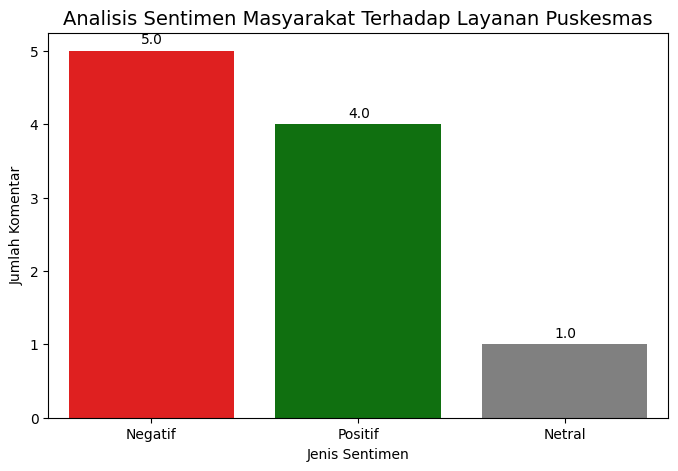

In [3]:
# 3. VISUALISASI HASIL
plt.figure(figsize=(8, 5))

# Membuat Bar Chart jumlah sentimen
ax = sns.countplot(x='sentimen', data=df, palette={'Positif': 'green', 'Negatif': 'red', 'Netral': 'grey'})

plt.title('Analisis Sentimen Masyarakat Terhadap Layanan Puskesmas', fontsize=14)
plt.xlabel('Jenis Sentimen')
plt.ylabel('Jumlah Komentar')

# Menampilkan angka di atas batang
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.35, p.get_height() + 0.1))

plt.show()

#Exercise 2

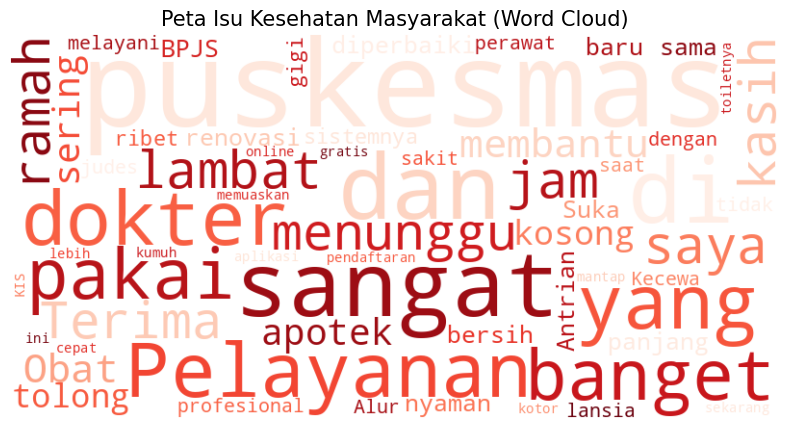

In [9]:

from wordcloud import WordCloud

# 1. Gabungkan semua teks komentar menjadi satu paragraf panjang
text_gabungan = ' '.join(df['text'])

# 2. Buat Word Cloud
# colormap 'Reds' supaya bernuansa urgensi/kesehatan
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_gabungan)

# 3. Tampilkan
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Hilangkan sumbu X dan Y agar rapi
plt.title('Peta Isu Kesehatan Masyarakat (Word Cloud)', fontsize=15)
plt.show()

In [10]:
import random

# Bank Kata untuk simulasi
masalah = ['antrian lama', 'obat habis', 'dokter telat', 'kamar penuh', 'suster judes', 'biaya mahal', 'rujukan ribet']
pujian = ['pelayanan cepat', 'dokter ramah', 'fasilitas bersih', 'sangat membantu', 'parkir luas', 'gratis bpjs']
lokasi = ['Poli Umum', 'Poli Gigi', 'IGD', 'Apotek', 'Pendaftaran', 'Ruang Rawat']

data_baru = []

# Generate 50 Komentar Negatif
for i in range(50):
    isu = random.choice(masalah)
    tempat = random.choice(lokasi)
    text = f"Kecewa banget di {tempat}, {isu}. Tolong diperbaiki!"
    data_baru.append(text)

# Generate 50 Komentar Positif
for i in range(50):
    puji = random.choice(pujian)
    tempat = random.choice(lokasi)
    text = f"Sangat puas ke {tempat}, {puji}. Pertahankan!"
    data_baru.append(text)

# Masukkan ke DataFrame baru
df = pd.DataFrame({'text': data_baru})

# Jalankan ulang analisis sentimen pada data baru ini
df['sentimen'] = df['text'].apply(cek_sentimen)

# Tampilkan sampel data
print(f"Berhasil membuat {len(df)} data simulasi!")
display(df.sample(5))

Berhasil membuat 100 data simulasi!


,text,sentimen
35,"Kecewa banget di Apotek, rujukan ribet. Tolong...",Negatif
7,"Kecewa banget di Ruang Rawat, obat habis. Tolo...",Negatif
59,"Sangat puas ke IGD, fasilitas bersih. Pertahan...",Positif
2,"Kecewa banget di Poli Umum, obat habis. Tolong...",Negatif
68,"Sangat puas ke Pendaftaran, sangat membantu. P...",Netral


/tmp/ipython-input-1027727053.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentimen', data=df, palette={'Positif': 'green', 'Negatif': 'red', 'Netral': 'grey'})


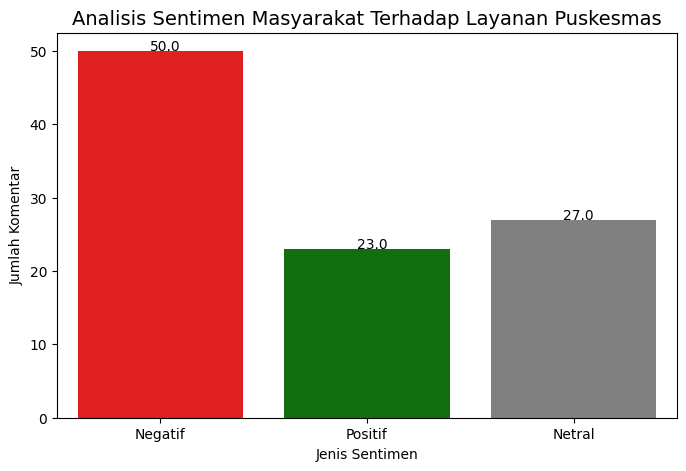

In [11]:
# 3. VISUALISASI HASIL
plt.figure(figsize=(8, 5))

# Membuat Bar Chart jumlah sentimen
ax = sns.countplot(x='sentimen', data=df, palette={'Positif': 'green', 'Negatif': 'red', 'Netral': 'grey'})

plt.title('Analisis Sentimen Masyarakat Terhadap Layanan Puskesmas', fontsize=14)
plt.xlabel('Jenis Sentimen')
plt.ylabel('Jumlah Komentar')

# Menampilkan angka di atas batang
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.35, p.get_height() + 0.1))

plt.show()